In [ ]:
# pyenv activate nitrates

In [2]:
import pandas as pd
from utils import *
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller

## Boyas UPCT

In [ ]:
# CCF - con ADF antes para ver si hay stationarity, si no la hay, descartar este test
# Two-Sample por pares de Kolmogorov Smirnov
# Correlación de Spearman? Si no se cumplen las condiciones de linearity, normality y homoscedasticity

In [1]:
path = "boyaUPCT/extractedData/"
buoy_id = "CTD7"

In [3]:
archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
dataframes = {}

# Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
for archivo in archivos_csv:
    nombre_variable = os.path.splitext(archivo)[0]
    ruta_completa = os.path.join(path, buoy_id, archivo)
    dataframes[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)

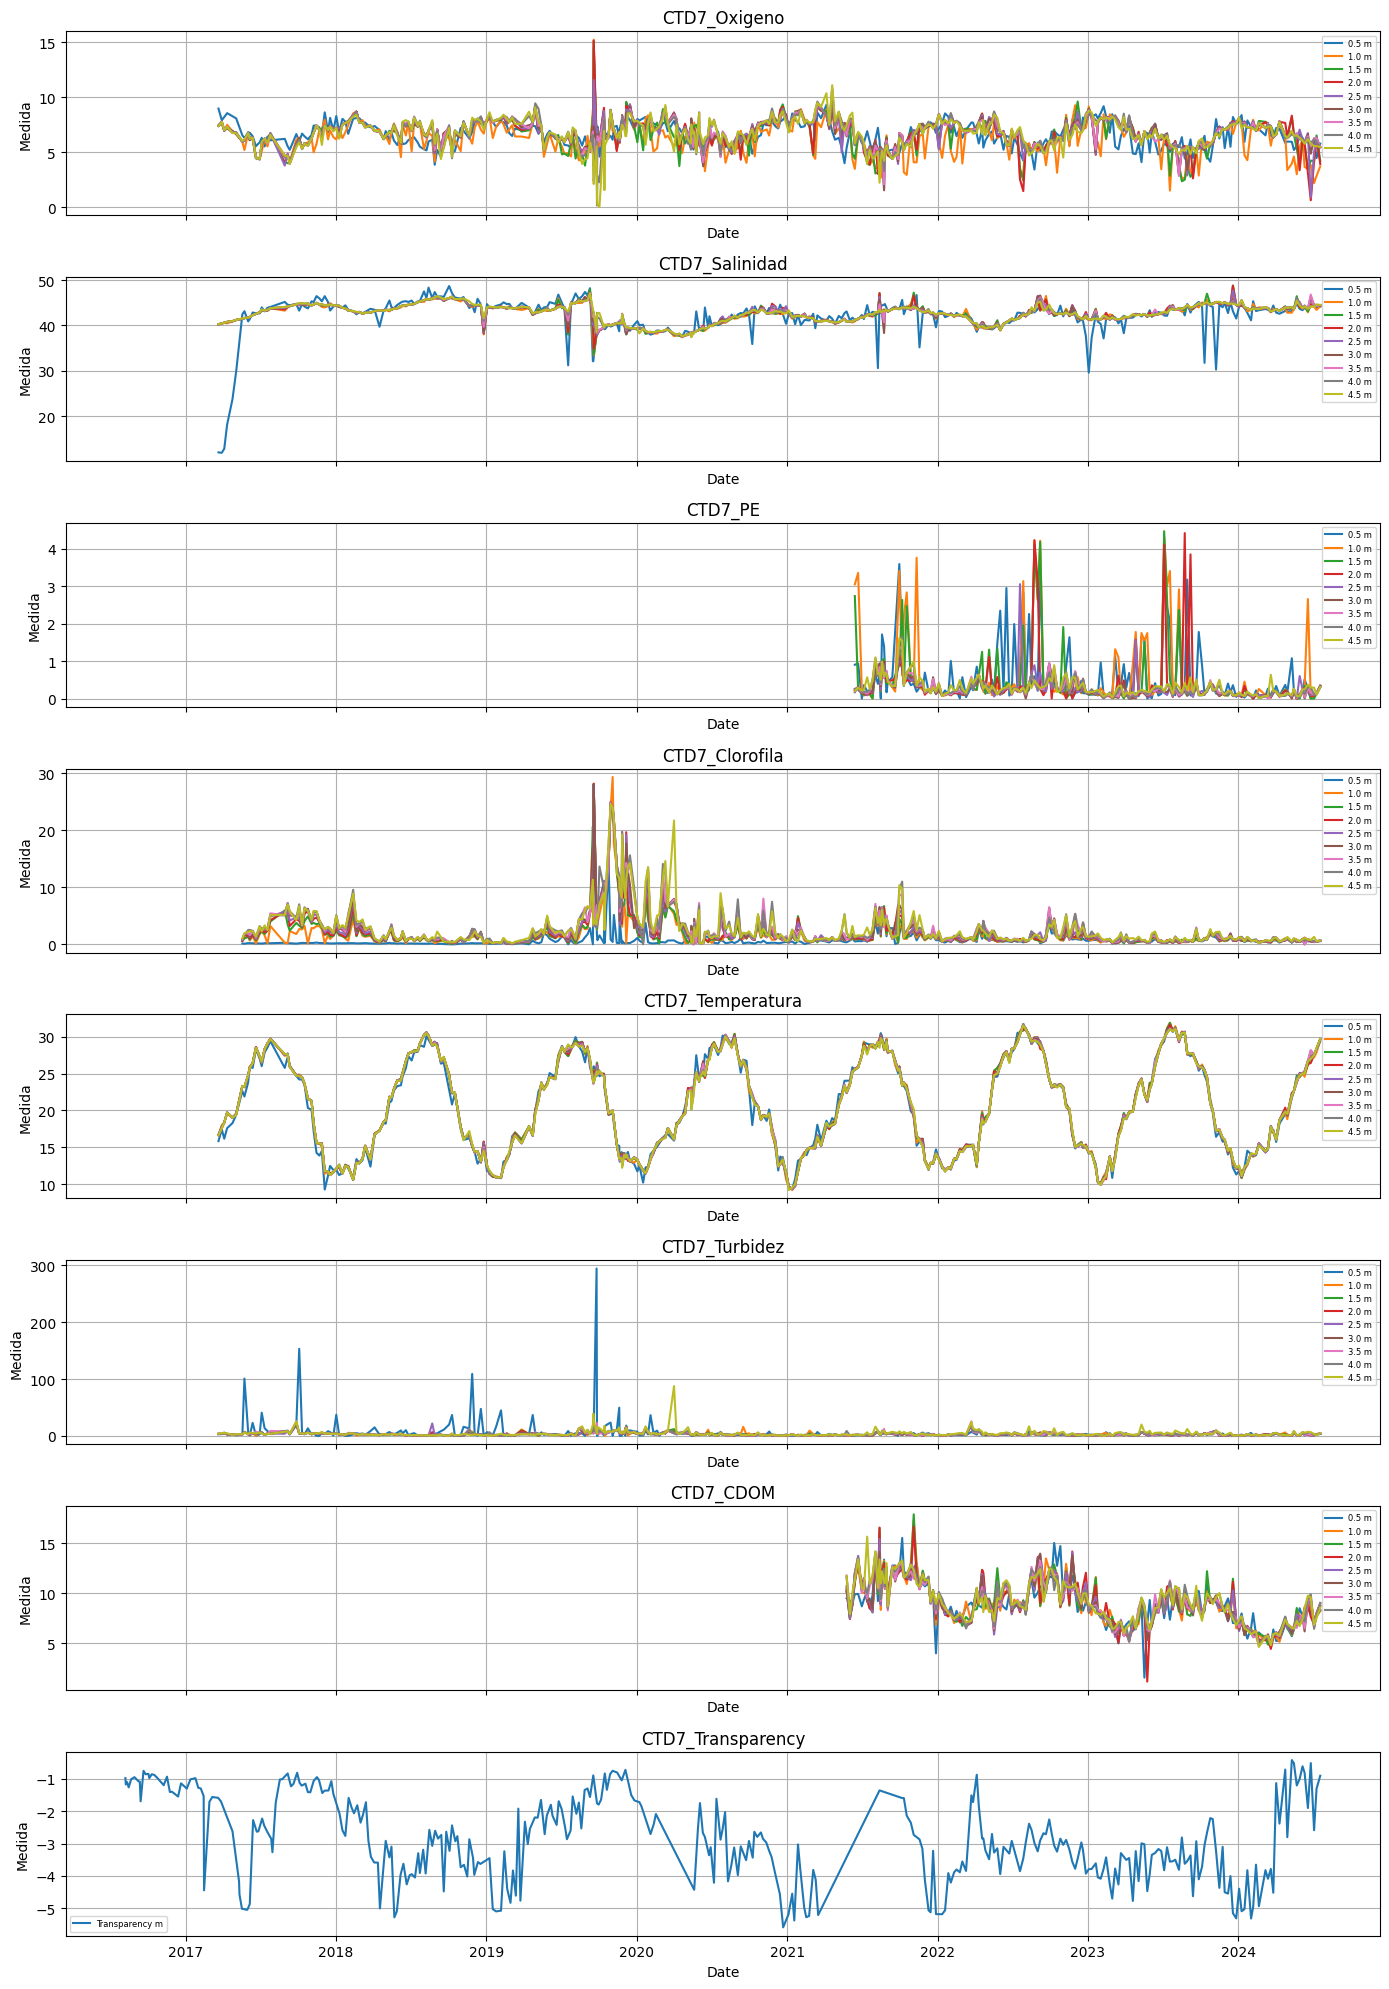

In [4]:
fig, ax = plt.subplots(figsize = (14,len(archivos_csv)*2.5), nrows=len(archivos_csv), ncols=1, sharex=True)

# Iterar sobre cada DataFrame y su correspondiente subplot
for i, (nombre, df) in enumerate(dataframes.items()):
    # Convertir la columna 'Fecha' a datetime
    df['Date'] = pd.to_datetime(df['Date'])
    # Graficar cada columna de profundidad
    for columna in df.columns:
        if columna != 'Date':
            ax[i].plot(df['Date'], df[columna], label=f'{columna} m')

    # Configurar el subplot
    ax[i].set_title(nombre)
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Medida')
    ax[i].legend(loc='best', fontsize=6)
    ax[i].grid(True)

fig.tight_layout()

#### Stationarity test

In [63]:
def adf_test(series, title=''):
    result = adfuller(series, autolag='AIC')
    #print(f'ADF Statistic for {title}: {result[0]}')
    #print(f'p-value for {title}: {result[1]}')
    #print(f'Critical Values for {title}: {result[4]}')
    if result[1] > 0.05:
        #print(f"Series {title} is non-stationary.")
        return 0
    else:
        #print(f"Series {title} is stationary.")
        return 1

In [64]:
for var in dataframes.keys():
    print(var)
    
    result = 0
    for col in dataframes[var].columns[1:]:
        result += adf_test(dataframes[var][col], f"{var} {col}")
    print(f"Porcentaje de series estacionarias: {result/len(dataframes[var].columns[1:])*100}")
    print("---"*60)

CTD4_Oxigeno
Porcentaje de series estacionarias: 100.0
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Salinidad
Porcentaje de series estacionarias: 60.0
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_PE
Porcentaje de series estacionarias: 50.0
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Clorofila
Porcentaje de series estacionarias: 40.0
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Temperatura
Porcentaje de series estacionarias: 100.0
-

#### CCF con los datos que tienen stationarity

CCF con Oxigeno, Temperatura y Turbidez

In [82]:
from statsmodels.graphics.tsaplots import plot_ccf # https://www.statsmodels.org/stable/_modules/statsmodels/graphics/tsaplots.html
# from statsmodels.tsa.stattools import ccf # Esto sería para no hacer un plot, sino sacar los valores directamente https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.ccf.html
import itertools
import seaborn as sns

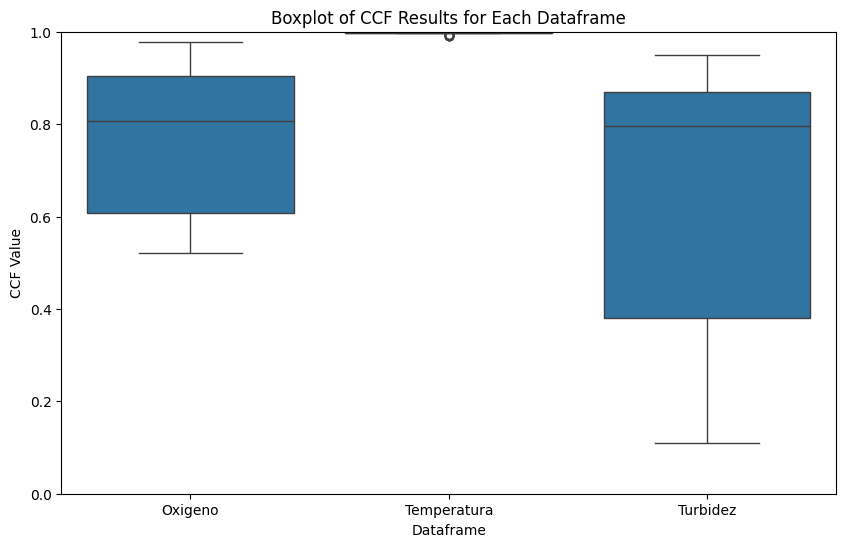

In [98]:
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import ccf

# Lista de dataframes
ccf_dfs = [CTD4_Oxigeno, CTD4_Temperatura, CTD4_Turbidez]
labels = ['Oxigeno', 'Temperatura', 'Turbidez']

# Lista para almacenar los resultados de ccf con sus etiquetas
ccf_valores = []

# Calcular la ccf para cada dataframe
for df, label in zip(ccf_dfs, labels):
    # Calcular la ccf para cada par de columnas
    for col1, col2 in list(itertools.combinations(df.columns[1:], 2)):
        ccf_resultado = ccf(df[col1], df[col2], adjusted=False, nlags=1)
        # Tomar el valor de ccf para lag 0
        ccf_valor = ccf_resultado[0]
        ccf_valores.append({'ccf': ccf_valor, 'label': label})

# Crear un DataFrame con los resultados
ccf_df = pd.DataFrame(ccf_valores)

# Generar el boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='ccf', data=ccf_df)
plt.title('Boxplot of CCF Results for Each Dataframe')
plt.xlabel('Dataframe')
plt.ylabel('CCF Value')
plt.ylim(0, 1)
plt.show()


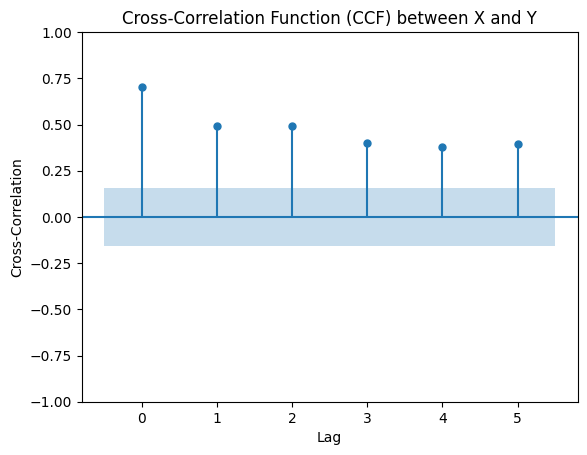

In [73]:
plot_ccf(CTD4_CDOM['0.5'], CTD4_CDOM['1.0'], lags=5)
plt.xlabel('Lag')
plt.ylabel('Cross-Correlation')
plt.title('Cross-Correlation Function (CCF) between X and Y')
plt.show()

#### Two Sample Kolmogorov-Smirnov Test

In [182]:
from scipy.stats import ks_2samp
import networkx as nx

In [183]:
#Two-Sample K-S Test
def ks_test(sample1, sample2, n_comparisons):
    stat, p_value = ks_2samp(sample1, sample2)
    #print(f'K-S Test Statistic (Two-Sample): {stat}')
    #print(f'P-value: {p_value}')

    alpha = 0.05
    alpha_adjusted = alpha/n_comparisons
    #print(f"alpha adjusted {alpha_adjusted}")
    if p_value > alpha_adjusted:
        #print("Fail to reject the null hypothesis: The two samples come from the same distribution.")
        return True
    else:
        #print("Reject the null hypothesis: The two samples come from different distributions.")
        return False

In [186]:
dataframes_filtered = {}

for var in dataframes.keys():
    print(var)
    df = dataframes[var]
    columnas = df.columns[1:] 

    # Grafo para agrupar profundidades similares
    G = nx.Graph()
    G.add_nodes_from(columnas)

    for col1, col2 in list(itertools.combinations(columnas, 2)):
        #print(f"{col1}, {col2}")
        if ks_test(dataframes[var][col1], dataframes[var][col2], len(list(itertools.combinations(dataframes[var].columns[1:], 2)))):
            G.add_edge(col1, col2)

    # Encontrar componentes conectados (grupos de profundidades que comparten la misma distribución)
    grupos = list(nx.connected_components(G))

    # Crear un nuevo DataFrame para almacenar los grupos filtrados
    df_filtered = pd.DataFrame(index=df.index)

    for i, grupo in enumerate(grupos):

        print(f"Grupo de profundidades con distribución común: {', '.join(grupo)}")
        # Añadir las columnas del grupo al DataFrame filtrado
        group_df = df[list(grupo)]
        df_filtered["Date"] = df["Date"]
        df_filtered[f'Grupo_{i+1}_Mean'] = group_df.mean(axis=1)

        # Añadir la desviación estándar si el grupo tiene más de un elemento
        if len(grupo) > 1:
            df_filtered[f'Grupo_{i+1}_Std'] = group_df.std(axis=1)

    dataframes_filtered[f"{var}_filtered"] = df_filtered

    print("---" * 60)

CTD4_Oxigeno
Grupo de profundidades con distribución común: 5.0, 1.5, 4.0, 0.5, 3.5, 2.5, 2.0, 3.0, 4.5
Grupo de profundidades con distribución común: 1.0
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Salinidad
Grupo de profundidades con distribución común: 1.5, 5.0, 4.0, 0.5, 3.5, 2.5, 1.0, 2.0, 3.0, 4.5
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_PE
Grupo de profundidades con distribución común: 1.5, 5.0, 4.0, 0.5, 3.5, 2.5, 1.0, 2.0, 3.0, 4.5
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Clorofila
Grupo de profundidades con distribución común: 0.5
Grupo de profundidade

#### Spearman correlation

In [119]:
for var in dataframes.keys():
    print(var)

    for col1, col2 in list(itertools.combinations(dataframes[var].columns[1:], 2)):
        print(f"{col1}, {col2}")
        print(dataframes[var][col1].corr(dataframes[var][col2], method='spearman'))
    print("---"*60)

CTD4_Oxigeno
0.5, 1.0
0.5851355406184878
0.5, 1.5
0.6187689478171532
0.5, 2.0
0.6370520740880287
0.5, 2.5
0.6403415413836835
0.5, 3.0
0.6430355058545234
0.5, 3.5
0.6445132171038706
0.5, 4.0
0.6320409166033859
0.5, 4.5
0.6304923179407304
0.5, 5.0
0.6417937622960531
1.0, 1.5
0.815073674356818
1.0, 2.0
0.79315708262365
1.0, 2.5
0.7803383563053868
1.0, 3.0
0.7571941013903645
1.0, 3.5
0.7482753966296434
1.0, 4.0
0.736117719716994
1.0, 4.5
0.725307389187436
1.0, 5.0
0.7154911817999965
1.5, 2.0
0.920654407352093
1.5, 2.5
0.9111224779132299
1.5, 3.0
0.889130871759814
1.5, 3.5
0.882082429437892
1.5, 4.0
0.8598322784379909
1.5, 4.5
0.8452010677780778
1.5, 5.0
0.8399711789256575
2.0, 2.5
0.9739406215952193
2.0, 3.0
0.9500952610307614
2.0, 3.5
0.930499746553221
2.0, 4.0
0.9240259292563037
2.0, 4.5
0.9086761338587419
2.0, 5.0
0.8838563141264049
2.5, 3.0
0.982545188298333
2.5, 3.5
0.9558898215385094
2.5, 4.0
0.9509663022600461
2.5, 4.5
0.9338943311432685
2.5, 5.0
0.9107340537307173
3.0, 3.5
0.975615

CTD4_Oxigeno


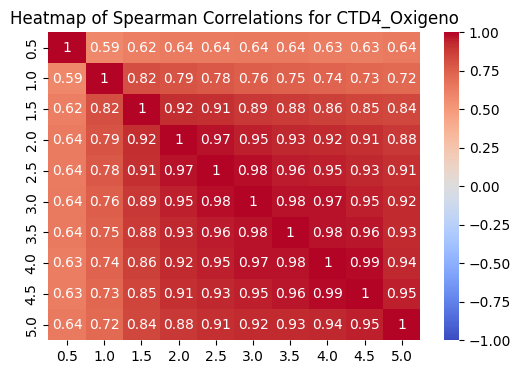

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Salinidad


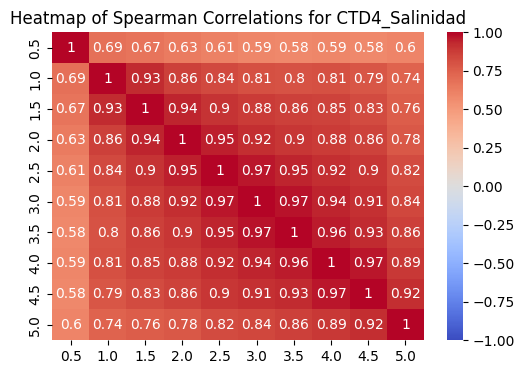

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_PE


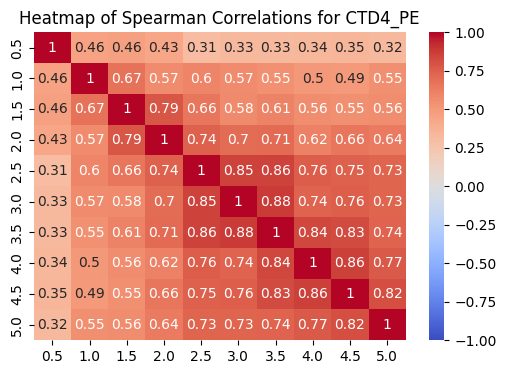

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Clorofila


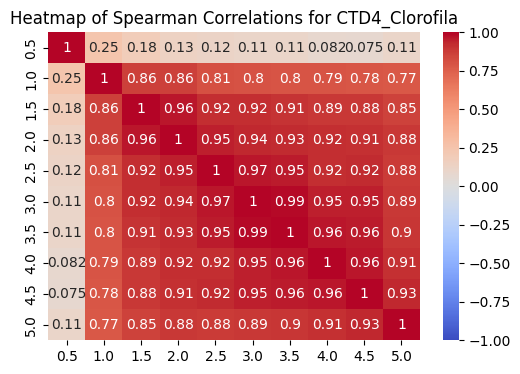

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Temperatura


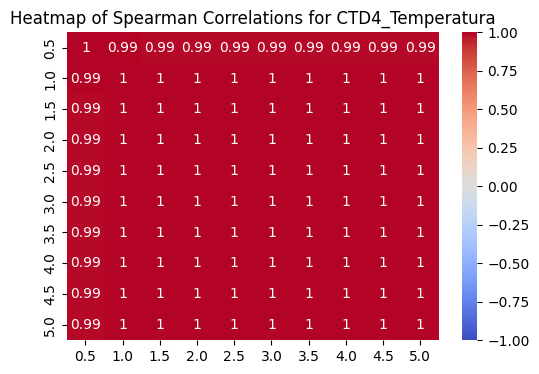

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Turbidez


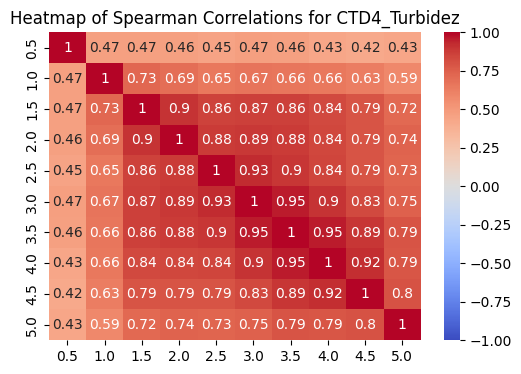

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_CDOM


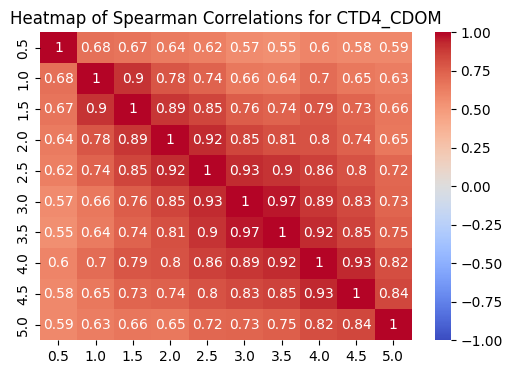

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
CTD4_Transparency


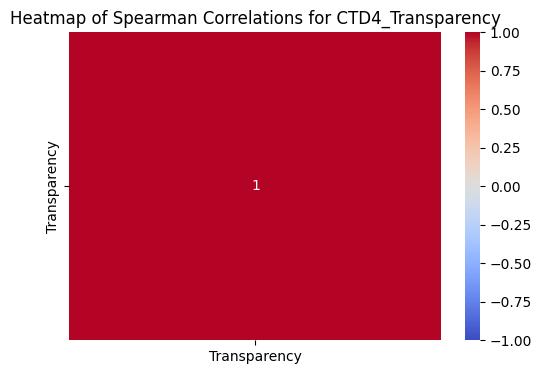

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [124]:
# Iterar sobre cada dataframe
for var in dataframes.keys():
    print(var)
    
    df = dataframes[var]
    columnas = df.columns[1:]  # Asumimos que la primera columna es 'Date' o similar y no se usa para las correlaciones
    corr_matrix = pd.DataFrame(index=columnas, columns=columnas)
    
    # Calcular la correlación para cada par de columnas
    for col1, col2 in itertools.combinations(columnas, 2):
        corr_value = df[col1].corr(df[col2], method='spearman')
        corr_matrix.loc[col1, col2] = corr_value
        corr_matrix.loc[col2, col1] = corr_value
    
    # Rellenar la diagonal con 1s (correlación de una columna consigo misma)
    for col in columnas:
        corr_matrix.loc[col, col] = 1.0
    
    # Convertir la matriz de correlación a valores numéricos (por si hay valores nulos)
    corr_matrix = corr_matrix.astype(float)
    
    # Mostrar la matriz de correlación
    # print(corr_matrix)
    
    # Crear el heatmap usando seaborn
    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Heatmap of Spearman Correlations for {var}')
    plt.show()
    
    print("---"*60)


### Proceso automático

In [190]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    
    # Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
    for archivo in archivos_csv:
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        dataframes[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)

In [197]:
#Two-Sample K-S Test
def ks_test(sample1, sample2, n_comparisons):
    stat, p_value = ks_2samp(sample1, sample2)
    #print(f'K-S Test Statistic (Two-Sample): {stat}')
    #print(f'P-value: {p_value}')

    alpha = 0.05
    alpha_adjusted = alpha/n_comparisons
    #print(f"alpha adjusted {alpha_adjusted}")
    if p_value > alpha_adjusted:
        #print("Fail to reject the null hypothesis: The two samples come from the same distribution.")
        return True
    else:
        #print("Reject the null hypothesis: The two samples come from different distributions.")
        return False


In [ ]:
# Diccionario para guardar los dataframes filtrados, una vez se hayan agrupado las profundidades 
dataframes_filtered = {}


for var in dataframes.keys():
    print(var)
    df = dataframes[var]
    columnas = df.columns[1:] 

    # Grafo para agrupar profundidades similares
    G = nx.Graph()
    G.add_nodes_from(columnas)

    for col1, col2 in list(itertools.combinations(columnas, 2)):
        #print(f"{col1}, {col2}")
        if ks_test(dataframes[var][col1], dataframes[var][col2], len(list(itertools.combinations(dataframes[var].columns[1:], 2)))):
            G.add_edge(col1, col2)

    # Encontrar componentes conectados (grupos de profundidades que comparten la misma distribución)
    grupos = list(nx.connected_components(G))

    # Crear un nuevo DataFrame para almacenar los grupos filtrados
    df_filtered = pd.DataFrame(index=df.index)
    df_filtered["Date"] = df["Date"]

    for i, grupo in enumerate(grupos):

        print(f"Grupo de profundidades con distribución común: {', '.join(grupo)}")
        # Añadir las columnas del grupo al DataFrame filtrado
        group_df = df[list(grupo)]
        df_filtered[f'Grupo_{i+1}_Mean'] = group_df.mean(axis=1)

        # Añadir la desviación estándar si el grupo tiene más de un elemento
        if len(grupo) > 1:
            df_filtered[f'Grupo_{i+1}_Std'] = group_df.std(axis=1)

    dataframes_filtered[f"{var}_filtered"] = df_filtered

    print("---" * 60)

In [195]:
dataframes_filtered.keys()

dict_keys(['CTD3_Oxigeno_filtered', 'CTD3_Salinidad_filtered', 'CTD3_PE_filtered', 'CTD3_Clorofila_filtered', 'CTD3_Temperatura_filtered', 'CTD3_Turbidez_filtered', 'CTD3_CDOM_filtered', 'CTD3_Transparency_filtered', 'CTD11_Oxigeno_filtered', 'CTD11_Salinidad_filtered', 'CTD11_PE_filtered', 'CTD11_Clorofila_filtered', 'CTD11_Temperatura_filtered', 'CTD11_Turbidez_filtered', 'CTD11_CDOM_filtered', 'CTD11_Transparency_filtered', 'CTD12_Oxigeno_filtered', 'CTD12_Salinidad_filtered', 'CTD12_PE_filtered', 'CTD12_Clorofila_filtered', 'CTD12_Temperatura_filtered', 'CTD12_Turbidez_filtered', 'CTD12_CDOM_filtered', 'CTD12_Transparency_filtered', 'CTD8_Oxigeno_filtered', 'CTD8_Salinidad_filtered', 'CTD8_PE_filtered', 'CTD8_Clorofila_filtered', 'CTD8_Temperatura_filtered', 'CTD8_Turbidez_filtered', 'CTD8_CDOM_filtered', 'CTD8_Transparency_filtered', 'CTD9_Oxigeno_filtered', 'CTD9_Salinidad_filtered', 'CTD9_PE_filtered', 'CTD9_Clorofila_filtered', 'CTD9_Temperatura_filtered', 'CTD9_Turbidez_filter

In [198]:
dataframes_filtered["CTD5_CDOM_filtered"]

,Date,Grupo_1_Mean,Grupo_1_Std,Grupo_2_Mean,Grupo_3_Mean,Grupo_3_Std,Grupo_4_Mean
0,2016-08-09,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-08-25,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-08-30,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-09-06,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-09-08,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
375,2024-02-20,0.513333,0.118462,1.88,4.905,0.374767,NaN
376,2024-03-07,0.100000,0.081854,0.55,3.045,0.657609,NaN
377,2024-03-13,1.006667,1.046438,3.74,4.325,0.035355,NaN
378,2024-03-20,0.426667,0.032146,0.77,3.925,0.487904,NaN
